# 🎓 Machine Learning Workbook
## Training and Evaluating a Model

---

**Welcome!** In this notebook, we are going to learn how machines learn from data — just like how you study for KCSE exams by practising past papers!

### By the end of this notebook, you will be able to:
1. Explain what a Machine Learning model is and how it is trained
2. Tell the difference between training data and new (unseen) data
3. Prepare data and train a model using Scikit-learn
4. Make predictions using a trained model
5. Evaluate how well a model performs
6. Improve a model using scaling and optimization techniques

---

### 📋 Table of Contents
1. [What is a Machine Learning Model?](#section1)
2. [How Training Works](#section2)
3. [Why We Evaluate a Model](#section3)
4. [Preparing Data for Training](#section4)
5. [Training a Model with Scikit-learn](#section5)
6. [Evaluating the Model](#section6)
7. [Model Optimization](#section7)
8. [Class Activity & Practice](#section8)

---
## Section 1: What is a Machine Learning Model? 🤖 <a id='section1'></a>

### Think of it like this...

Imagine **Wanjiku** is studying at **Alliance High School**. Every day she reads past papers, checks the answers, and learns from her mistakes. After doing this many times, she gets good at predicting what kind of questions will appear in KCSE.

A **Machine Learning (ML) model** works the same way:
- It looks at **lots of examples** (data)
- It finds **patterns** in that data
- It uses those patterns to **make predictions** on new examples it has never seen before

---

### Real-life ML examples you already use:
| Application | What it predicts |
|-------------|------------------|
| M-Pesa fraud detection | Is this transaction fraudulent? |
| Spotify / YouTube | What song/video will you like next? |
| Google Translate | What does this Swahili sentence mean in English? |
| Hospitals (like KNH) | Does this patient have a disease? |

---

### Two main types of ML problems(Supervised Learning is Our Focus):

**1. Classification** — predicting a *category* (a group/label)
> Example: Will Kamau pass or fail his exam? (Pass / Fail)

**2. Regression** — predicting a *number*
> Example: What GPA will Aisha get this term? (e.g., 3.2, 2.8, 1.5)

---

> 💡 **Key Vocabulary**
> - **Model** — the "brain" that has learned from data
> - **Training** — the process of teaching the model using examples
> - **Features** — the input information we give the model (like study hours, absences)
> - **Target** — what we want the model to predict (like GPA or grade class)

---
## Section 2: How Training Works 🏋️ <a id='section2'></a>

### The Story of Coach Omondi's Football Team

Coach **Omondi** trains the **Gor Mahia** youth team. Here is how he does it:

1. He shows players **many match videos** (the training data)
2. He explains what **good moves** look like (the correct answers / labels)
3. Players **practice** and get feedback (the learning process)
4. He tests them in a **real match** they haven't played before (testing on new data)

Machine Learning works the same way:

```
    Training Data ──► ML Algorithm ──► Trained Model ──► Predictions
         │                                                     │
    (past examples                                    (answers for new
     with answers)                                     examples)
```

---

### Training Data vs. New (Unseen) Data

| | Training Data | New / Test Data |
|--|---------------|-----------------|
| **What it is** | Data the model learns from | Data the model has never seen |
| **Analogy** | Past KCSE papers Wanjiku studied | The actual KCSE exam |
| **Used for** | Teaching the model | Checking if the model really learned |

### ⚠️ Why is this distinction important?

If Wanjiku **memorises only the past papers word-for-word** without understanding, she will fail the actual exam because the questions are different. This is called **overfitting** in ML — the model only memorises training data and fails on new data.

We want our model to **generalise** — learn the patterns, not just memorise!

---
## Section 3: Why We Evaluate a Model 📊 <a id='section3'></a>

Imagine you trained a model to predict whether a student will pass or fail. Before you trust it to make real decisions, you need to ask:

> *"How often does my model get the right answer?"*

This is what **evaluation** is — measuring how good your model is.

### Why evaluation matters:
- A model that is 50% accurate is as good as flipping a coin — not useful!
- A doctor using AI at **Kenyatta National Hospital** needs to know: is this model reliable?
- We evaluate to decide if a model is ready to be used in the real world

### Evaluation metrics we will use:

**For Classification (predicting categories):**
- **Accuracy** — what percentage of predictions were correct?
- **Confusion Matrix** — a table showing correct vs. wrong predictions
- **Classification Report** — precision, recall, F1-score

**For Regression (predicting numbers):**
- **MAE (Mean Absolute Error)** — on average, how far off was the model?
- **RMSE (Root Mean Squared Error)** — similar, but punishes big mistakes more
- **R² Score** — how well does the model explain the data? (0 = bad, 1 = perfect)

---
## Section 4: Preparing Data for Training 🔧 <a id='section4'></a>

Before we can train any model, we need to:
1. **Load the data**
2. **Explore and clean it**
3. **Split into Features (X) and Target (y)**
4. **Split into Training and Testing sets**

We'll use real student data to predict **GradeClass** (A, B, C, D, or F).

In [1]:
# First, let's import all the libraries we'll need
# Think of libraries as your school bag - they contain tools you need for class!

import pandas as pd                    # For working with data (like Excel in Python)
import numpy as np                     # For math operations
import matplotlib.pyplot as plt        # For creating charts
import seaborn as sns                  # For beautiful charts

# Scikit-learn tools - our Machine Learning toolkit!
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

# Make our charts look nice
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("✅ All libraries loaded successfully! We are ready to go!")

✅ All libraries loaded successfully! We are ready to go!


In [2]:
# ── Step 1: Load the data ──────────────────────────────────────────────────
# This is student performance data - imagine these are students from schools

df = pd.read_csv('../Data_literacy/data/Student_performance_data.csv')
print(f"📁 Data loaded!")
print("\n🔍 First 5 rows of our data:")
df.head()

📁 Data loaded!

🔍 First 5 rows of our data:


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [3]:
# ── Step 2: Explore the data ──────────────────────────────────────────────
# What columns do we have? What do they mean?

print(f"We have {df.shape[0]} students and {df.shape[1]} columns.")

print("\n📋 Column names:")
print(df.columns)


print("\n📊 Data types:")
print(df.dtypes)

print("\n📊 Basic statistics:")
df.describe().round(2)

We have 2392 students and 15 columns.

📋 Column names:
Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

📊 Data types:
StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

📊 Basic statistics:


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.00,2392.00,2392.00,2392.00,2392.00,2392.00,2392.00,2392.00,2392.00,2392.00,2392.00,2392.0,2392.00,2392.00,2392.00
mean,2196.50,16.47,0.51,0.88,1.75,9.77,14.54,0.30,2.12,0.38,0.30,0.2,0.16,1.91,2.98
std,690.66,1.12,0.50,1.03,1.00,5.65,8.47,0.46,1.12,0.49,0.46,0.4,0.36,0.92,1.23
min,1001.00,15.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,1598.75,15.00,0.00,0.00,1.00,5.04,7.00,0.00,1.00,0.00,0.00,0.0,0.00,1.17,2.00
50%,2196.50,16.00,1.00,0.00,2.00,9.71,15.00,0.00,2.00,0.00,0.00,0.0,0.00,1.89,4.00
75%,2794.25,17.00,1.00,2.00,2.00,14.41,22.00,1.00,3.00,1.00,1.00,0.0,0.00,2.62,4.00
max,3392.00,18.00,1.00,3.00,4.00,19.98,29.00,1.00,4.00,1.00,1.00,1.0,1.00,4.00,4.00


In [4]:
# ── Check for missing values ───────────────────────────────────────────────
# Like checking if someone forgot to fill in their form at school!

missing = df.isnull().sum()
print("❓ Missing values in each column:")
print(missing)

print(f"\n✅ Total missing values: {missing.sum()}")
# Great - no missing values! Our data is clean.

❓ Missing values in each column:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

✅ Total missing values: 0


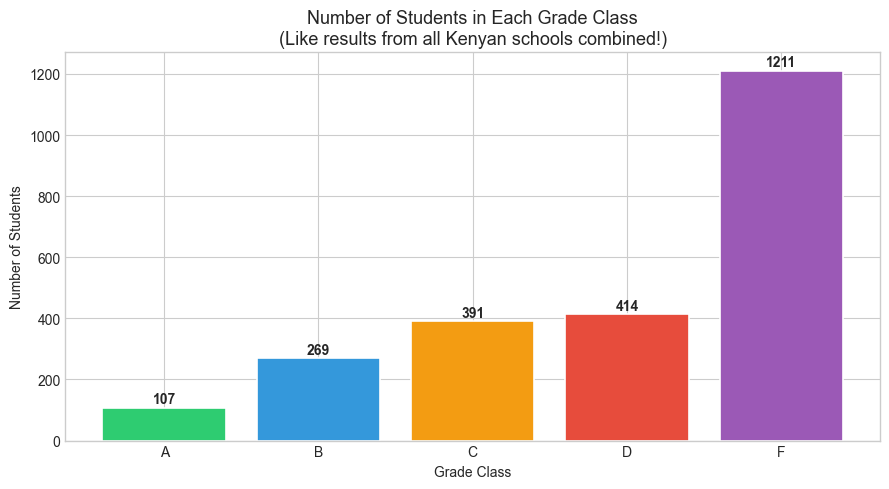


📊 Grade distribution:
  Grade A: 107 students (4.5%)
  Grade B: 269 students (11.2%)
  Grade C: 391 students (16.3%)
  Grade D: 414 students (17.3%)
  Grade F: 1211 students (50.6%)


In [8]:
# ── Visualise the target variable ─────────────────────────────────────────
# Let's see how many students are in each grade class

# Map grade class numbers to letter grades for better understanding

# To understand this code better, comment each line from the base up and run each block at a time.

grade_labels = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F'}

grade_counts = df['GradeClass'].value_counts().sort_index()

plt.figure(figsize=(9, 5))
bars = plt.bar(
    [grade_labels[i] for i in grade_counts.index],
    grade_counts.values,
    color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6'],
    edgecolor='white', linewidth=1.2
)

#Add count labels on bars
for bar, count in zip(bars, grade_counts.values):
     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
              str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Number of Students in Each Grade Class\n(Like results from all Kenyan schools combined!)', fontsize=13)
plt.xlabel('Grade Class')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

print("\n📊 Grade distribution:")
for code, label in grade_labels.items():
    count = (df['GradeClass'] == code).sum()
    pct = count / len(df) * 100
    print(f"  Grade {label}: {count} students ({pct:.1f}%)")

In [11]:
# ── Step 3: Split Features (X) and Target (y) ─────────────────────────────
#
# 🎒 Features (X) = the information we USE to make a prediction
#    Think: study hours, absences, parental support, etc.
#
# 🎯 Target (y) = what we WANT to predict
#    Think: GradeClass (A, B, C, D, or F)

# We drop StudentID (not useful for prediction) and GPA (it directly determines GradeClass)
features_to_drop = ['StudentID', 'GPA', 'GradeClass']

X = df.drop(columns=features_to_drop)   # Features
y = df['GradeClass'] 


print(f"🎒 Features (X) shape: {X.shape}  → {X.shape[0]} students, {X.shape[1]} features")
print(f"🎯 Target (y) shape:   {y.shape}  → one grade label per student")
print("\n📋 Feature columns we are using:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

🎒 Features (X) shape: (2392, 12)  → 2392 students, 12 features
🎯 Target (y) shape:   (2392,)  → one grade label per student

📋 Feature columns we are using:
   1. Age
   2. Gender
   3. Ethnicity
   4. ParentalEducation
   5. StudyTimeWeekly
   6. Absences
   7. Tutoring
   8. ParentalSupport
   9. Extracurricular
  10. Sports
  11. Music
  12. Volunteering


In [12]:
# ── Step 4: Split into Training and Testing sets ───────────────────────────
#
# We split our data into two groups:
#   📚 Training set (80%) — the model LEARNS from this
#   🧪 Testing set  (20%) — we use this to CHECK the model later
#
# Analogy: Imagine Amina is studying for KCSE.
#   Training = the 80% of past papers she studies from
#   Testing  = the 20% of papers she sets aside to test herself

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% goes to testing
    random_state=42,    # ensures we get same split every time (reproducibility)
    stratify=y          # ensures each grade class is proportionally represented
)

print("✂️ Data split complete!")
print(f"   📚 Training set:   {X_train.shape[0]} students ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   🧪 Testing set:    {X_test.shape[0]} students  ({X_test.shape[0]/len(X)*100:.0f}%)")
print("\n💡 The model will NEVER see the test data during training.")
print("   This is how we make sure our evaluation is fair!")

✂️ Data split complete!
   📚 Training set:   1913 students (80%)
   🧪 Testing set:    479 students  (20%)

💡 The model will NEVER see the test data during training.
   This is how we make sure our evaluation is fair!


---
## Section 5: Training a Model with Scikit-learn 🧠 <a id='section5'></a>

Now for the exciting part — we teach the machine to learn!

We'll train two types of models:
1. **Decision Tree** — makes decisions like a flowchart
2. **Random Forest** — a team of many decision trees working together

### Decision Tree — The Simple Explainer

Imagine a teacher asking questions to figure out if a student studied:
```
Did you study more than 10 hours this week?
        ├── YES → Did you have less than 5 absences?
        │           ├── YES → Likely Grade A or B ✅
        │           └── NO  → Likely Grade C
        └── NO  → Did you have tutoring?
                    ├── YES → Likely Grade C or D
                    └── NO  → Likely Grade D or F ❌
```

That branching structure is exactly what a Decision Tree does with the data!

In [13]:
# ── Train a Decision Tree Classifier ──────────────────────────────────────
# Step 1: Create the model (like buying a new textbook)
dt_model = DecisionTreeClassifier(
    max_depth=5,        # limit how deep the tree grows (avoids overfitting)
    random_state=42
)

# Step 2: Train the model (like studying from that textbook)
# .fit() is the magic command that does the learning!
dt_model.fit(X_train, y_train)

print("🌳 Decision Tree model trained!")
print(f"   Tree depth: {dt_model.get_depth()}")
print(f"   Number of leaves (end nodes): {dt_model.get_n_leaves()}")

🌳 Decision Tree model trained!
   Tree depth: 5
   Number of leaves (end nodes): 30


In [14]:
# ── Make Predictions ──────────────────────────────────────────────────────
# Now let's ask the model: "What grade will these test students get?"

# Predict grades for our test students
dt_predictions = dt_model.predict(X_test)

print("🔮 Predictions made for test students!")
print(f"   First 10 predictions: {dt_predictions[:10]}")
print(f"   First 10 actual:      {y_test.values[:10]}")

# Let's make this more readable
print("\n📋 Comparing predictions vs actual (first 10 students):")
grade_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F'}
comparison = pd.DataFrame({
    'Predicted Grade': [grade_map[p] for p in dt_predictions[:10]],
    'Actual Grade':    [grade_map[a] for a in y_test.values[:10]],
    'Correct?':        ['✅' if p == a else '❌'
                        for p, a in zip(dt_predictions[:10], y_test.values[:10])]
})
print(comparison.to_string(index=False))

🔮 Predictions made for test students!
   First 10 predictions: [4. 4. 4. 4. 1. 3. 1. 3. 4. 4.]
   First 10 actual:      [4. 4. 4. 4. 2. 3. 2. 4. 4. 3.]

📋 Comparing predictions vs actual (first 10 students):
Predicted Grade Actual Grade Correct?
              F            F        ✅
              F            F        ✅
              F            F        ✅
              F            F        ✅
              B            C        ❌
              D            D        ✅
              B            C        ❌
              D            F        ❌
              F            F        ✅
              F            D        ❌


In [15]:
# ── Train a Random Forest Classifier ──────────────────────────────────────
# Random Forest = many decision trees voting together!
# Like asking 100 teachers instead of 1 — the majority vote wins

rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees in the forest
    max_depth=7,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print("🌲🌲🌲 Random Forest trained with 100 trees!")
print(f"   Training accuracy: {rf_model.score(X_train, y_train)*100:.1f}%")

🌲🌲🌲 Random Forest trained with 100 trees!
   Training accuracy: 83.5%


---
## Section 6: Evaluating the Model 📏 <a id='section6'></a>

Now let's measure how good our models are. Remember — we test them on data they've **never seen before** (the test set)!

### Key Metrics Explained Simply:

| Metric | What it means | Analogy |
|--------|--------------|--------|
| **Accuracy** | % of correct predictions | If Njoroge gets 80 out of 100 exam questions right, his accuracy is 80% |
| **Precision** | When model says "A", how often is it actually A? | If Akinyi picks 10 mangoes claiming they're ripe, how many really are? |
| **Recall** | Out of all actual A's, how many did model find? | Out of all ripe mangoes in the basket, how many did Akinyi pick? |
| **F1-Score** | Balance between precision and recall | A combined score |

In [16]:
# ── Evaluate both models ───────────────────────────────────────────────────

dt_accuracy  = accuracy_score(y_test, dt_predictions)
rf_accuracy  = accuracy_score(y_test, rf_predictions)

print("═" * 50)
print("       MODEL EVALUATION RESULTS")
print("═" * 50)
print(f"  🌳 Decision Tree Accuracy:  {dt_accuracy*100:.2f}%")
print(f"  🌲 Random Forest Accuracy:  {rf_accuracy*100:.2f}%")
print("═" * 50)

winner = "Random Forest" if rf_accuracy > dt_accuracy else "Decision Tree"
print(f"\n🏆 Winner: {winner}!")

══════════════════════════════════════════════════
       MODEL EVALUATION RESULTS
══════════════════════════════════════════════════
  🌳 Decision Tree Accuracy:  69.10%
  🌲 Random Forest Accuracy:  70.35%
══════════════════════════════════════════════════

🏆 Winner: Random Forest!


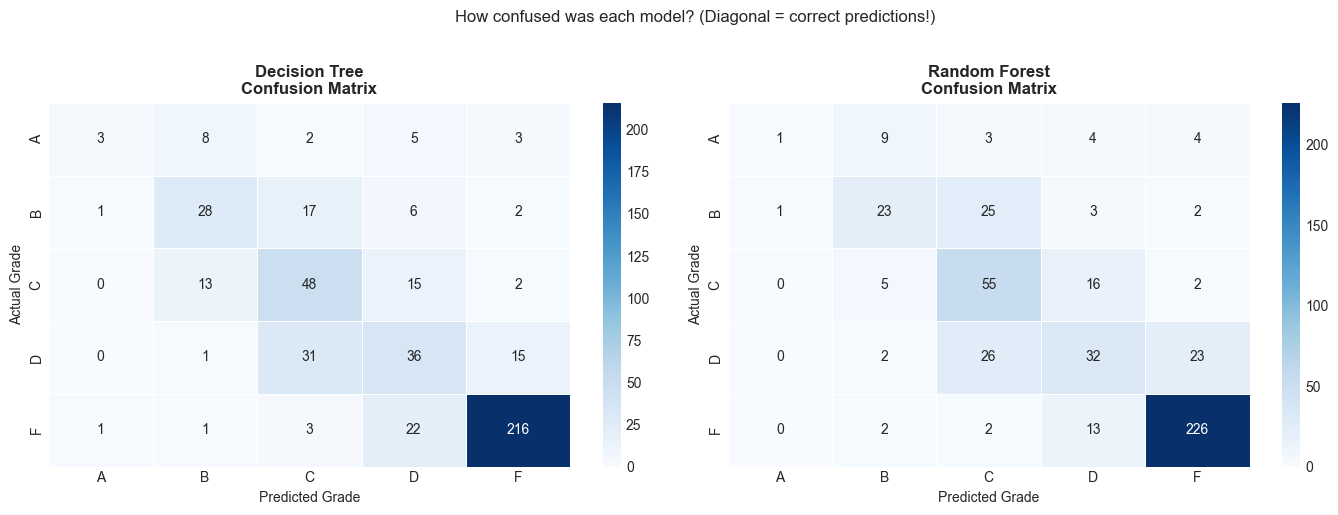

💡 Reading the matrix:
   • Numbers on the diagonal (top-left to bottom-right) = CORRECT predictions
   • Numbers off the diagonal = mistakes (the model predicted wrong grade)
   • The bigger the diagonal numbers, the better!


In [17]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
# A confusion matrix shows us exactly where the model got confused
# Rows = Actual grade, Columns = What model predicted

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
grade_names = ['A', 'B', 'C', 'D', 'F']

for ax, (name, preds) in zip(axes, [
    ('Decision Tree', dt_predictions),
    ('Random Forest', rf_predictions)
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=grade_names, yticklabels=grade_names,
        ax=ax, linewidths=0.5
    )
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Grade')
    ax.set_ylabel('Actual Grade')

plt.suptitle('How confused was each model? (Diagonal = correct predictions!)', y=1.02)
plt.tight_layout()
plt.show()

print("💡 Reading the matrix:")
print("   • Numbers on the diagonal (top-left to bottom-right) = CORRECT predictions")
print("   • Numbers off the diagonal = mistakes (the model predicted wrong grade)")
print("   • The bigger the diagonal numbers, the better!")

In [18]:
# ── Full Classification Report ─────────────────────────────────────────────
# This gives us precision, recall and F1-score for each grade class

print("🌲 Random Forest - Detailed Report:")
print("=" * 55)
print(classification_report(
    y_test, rf_predictions,
    target_names=['Grade A', 'Grade B', 'Grade C', 'Grade D', 'Grade F']
))
print("\n💡 Explanation:")
print("   precision = when model says 'Grade A', how often is it correct?")
print("   recall    = of ALL actual 'Grade A' students, how many did we catch?")
print("   f1-score  = balanced score combining both (higher is better)")
print("   support   = how many students actually have that grade in test data")

🌲 Random Forest - Detailed Report:
              precision    recall  f1-score   support

     Grade A       0.50      0.05      0.09        21
     Grade B       0.56      0.43      0.48        54
     Grade C       0.50      0.71      0.58        78
     Grade D       0.47      0.39      0.42        83
     Grade F       0.88      0.93      0.90       243

    accuracy                           0.70       479
   macro avg       0.58      0.50      0.50       479
weighted avg       0.69      0.70      0.69       479


💡 Explanation:
   precision = when model says 'Grade A', how often is it correct?
   recall    = of ALL actual 'Grade A' students, how many did we catch?
   f1-score  = balanced score combining both (higher is better)
   support   = how many students actually have that grade in test data


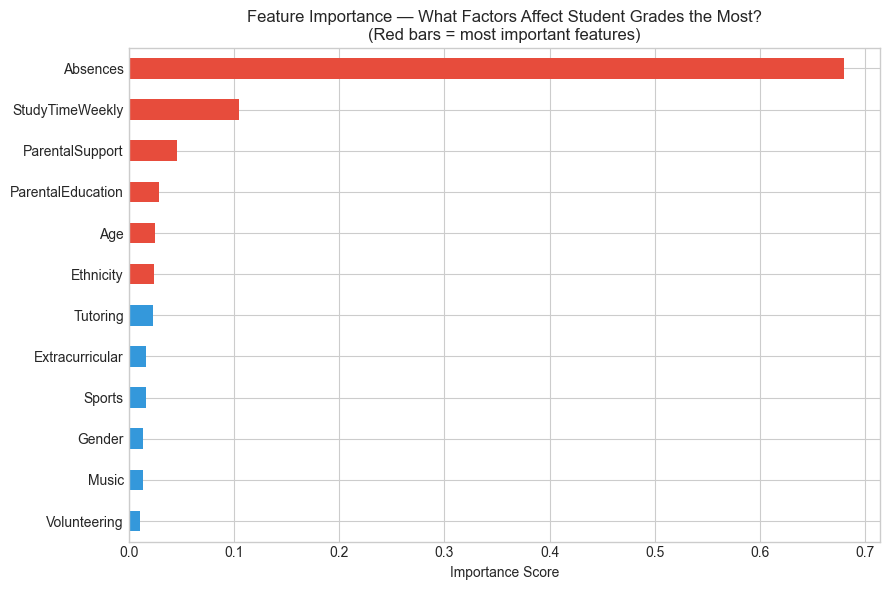

🔝 Top 3 most important features:
   • Absences: 0.6798
   • StudyTimeWeekly: 0.1045
   • ParentalSupport: 0.0456


In [19]:
# ── Feature Importance ─────────────────────────────────────────────────────
# Which features does the Random Forest think are most important for predicting grades?
# Like asking: "What matters most for a student's grade?"

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#e74c3c' if v > importances.median() else '#3498db' for v in importances.values]
importances.plot(kind='barh', color=colors)
plt.title('Feature Importance — What Factors Affect Student Grades the Most?\n'
          '(Red bars = most important features)', fontsize=12)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("🔝 Top 3 most important features:")
top3 = importances.sort_values(ascending=False).head(3)
for feature, score in top3.items():
    print(f"   • {feature}: {score:.4f}")

---
## Bonus: Regression — Predicting GPA (a Number) 📈

So far we predicted **categories** (Grade A, B, C...). Now let's predict the actual **GPA number**.

This is a **regression** problem — predicting a continuous number.

> Example: Can we predict that Baraka will get a GPA of **3.4** this term?

In [20]:
# ── Regression: Predict GPA ────────────────────────────────────────────────

# This time our target is GPA (a number, not a category)
X_reg = df.drop(columns=['StudentID', 'GPA', 'GradeClass'])
y_reg = df['GPA']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Train a Random Forest for regression
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_r, y_train_r)

# Make predictions
y_pred_gpa = rf_regressor.predict(X_test_r)

# Evaluate using regression metrics
mae  = mean_absolute_error(y_test_r, y_pred_gpa)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_gpa))
r2   = r2_score(y_test_r, y_pred_gpa)

print("📏 Regression Evaluation (Predicting GPA):")
print(f"   MAE  (Mean Absolute Error) : {mae:.4f}")
print(f"       → On average, our GPA prediction is off by {mae:.2f} points")
print(f"   RMSE (Root Mean Sq Error)  : {rmse:.4f}")
print(f"   R²   (Explains variance)   : {r2:.4f}")
print(f"       → The model explains {r2*100:.1f}% of the variation in GPA")
print()
print("📊 Sample predictions vs actual GPA:")
sample = pd.DataFrame({
    'Actual GPA':    y_test_r.values[:8].round(2),
    'Predicted GPA': y_pred_gpa[:8].round(2),
    'Error':         (y_test_r.values[:8] - y_pred_gpa[:8]).round(2)
})
print(sample.to_string(index=False))

📏 Regression Evaluation (Predicting GPA):
   MAE  (Mean Absolute Error) : 0.1908
       → On average, our GPA prediction is off by 0.19 points
   RMSE (Root Mean Sq Error)  : 0.2460
   R²   (Explains variance)   : 0.9268
       → The model explains 92.7% of the variation in GPA

📊 Sample predictions vs actual GPA:
 Actual GPA  Predicted GPA  Error
       1.43           1.32   0.11
       3.12           2.98   0.13
       2.04           1.85   0.19
       3.55           3.38   0.17
       0.25           0.42  -0.17
       2.63           2.53   0.10
       2.06           1.46   0.60
       2.25           2.14   0.11


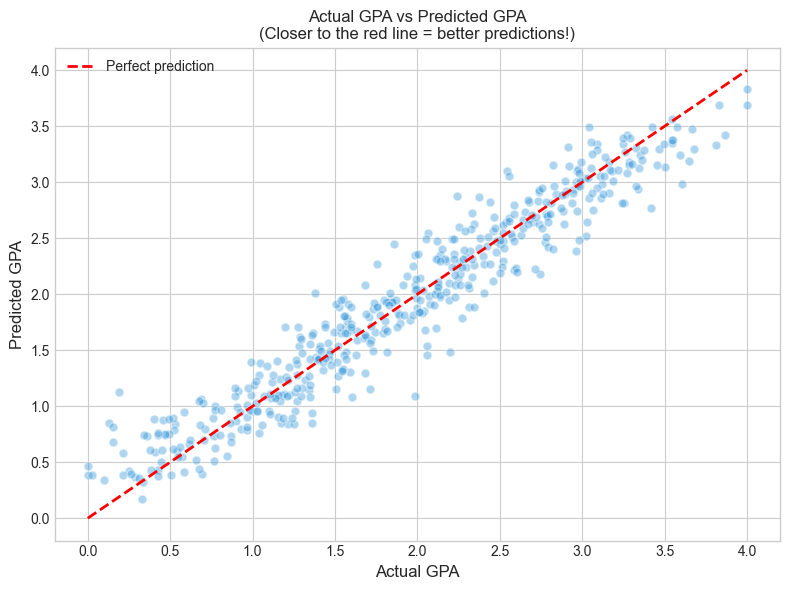

💡 If all points were ON the red line, the model would be perfect!
   Points scattered around it = the model is still learning well.


In [21]:
# ── Visualise Predictions vs Actual GPA ───────────────────────────────────

plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_gpa, alpha=0.4, color='#3498db', edgecolors='white', s=40)

# Perfect prediction line
min_val, max_val = y_test_r.min(), y_test_r.max()
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual GPA', fontsize=12)
plt.ylabel('Predicted GPA', fontsize=12)
plt.title('Actual GPA vs Predicted GPA\n(Closer to the red line = better predictions!)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print("💡 If all points were ON the red line, the model would be perfect!")
print("   Points scattered around it = the model is still learning well.")

---
## Section 7: Model Optimization — Making it Better! 🚀 <a id='section7'></a>

### Why Optimize?

Think of building a model like making **Ugali**. You need the right amount of water, heat, and time. Too much or too little of any ingredient ruins it!

In ML, models have **hyperparameters** — settings we control before training. Examples:
- `max_depth` — how deep should the tree grow?
- `n_estimators` — how many trees in the forest?
- `min_samples_split` — how many samples needed to split a node?

**Optimization** = finding the best combination of these settings.

### Two popular methods:

| Method | How it works | Speed |
|--------|-------------|-------|
| **Grid Search** | Try EVERY possible combination | Slow but thorough |
| **Random Search** | Try RANDOM combinations | Faster, still good |

In [22]:
# ── Step 1: Feature Scaling ────────────────────────────────────────────────
# Some ML models work better when all features are on the same scale
# Imagine comparing a student's height (1.7m) with their study hours (15)
# — very different scales! Scaling brings them to the same range.
#
# StandardScaler: transforms features so mean=0 and std=1
# (Like converting different currencies to Kenyan Shillings for fair comparison)

scaler = StandardScaler()

# Fit on training data, then transform both train and test
# IMPORTANT: We fit ONLY on train data — the test data should be "new" to everything!
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # Only transform, do NOT fit again!

print("⚖️ Feature Scaling applied!")
print(f"   Before scaling — StudyTimeWeekly mean: {X_train['StudyTimeWeekly'].mean():.2f}")
print(f"   After scaling  — StudyTimeWeekly mean: {X_train_scaled[:, list(X.columns).index('StudyTimeWeekly')].mean():.4f} (≈0)")
print("\n💡 Scaling helps algorithms like KNN and Logistic Regression work much better!")

⚖️ Feature Scaling applied!
   Before scaling — StudyTimeWeekly mean: 9.69
   After scaling  — StudyTimeWeekly mean: -0.0000 (≈0)

💡 Scaling helps algorithms like KNN and Logistic Regression work much better!


In [23]:
# ── Compare KNN with and without scaling ──────────────────────────────────
# K-Nearest Neighbors (KNN) measures distance between students
# Without scaling, large-valued features dominate the distance calculation!

knn = KNeighborsClassifier(n_neighbors=5)

# Without scaling
knn.fit(X_train, y_train)
acc_no_scale = accuracy_score(y_test, knn.predict(X_test))

# With scaling
knn.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, knn.predict(X_test_scaled))

print("📊 Effect of Scaling on KNN (K=5):")
print(f"   Without scaling: {acc_no_scale*100:.2f}% accuracy")
print(f"   With scaling:    {acc_scaled*100:.2f}% accuracy")
improvement = (acc_scaled - acc_no_scale) * 100
print(f"   Improvement:     {improvement:+.2f} percentage points")
print("\n✅ Scaling usually helps — always try it!")

📊 Effect of Scaling on KNN (K=5):
   Without scaling: 65.34% accuracy
   With scaling:    56.37% accuracy
   Improvement:     -8.98 percentage points

✅ Scaling usually helps — always try it!


In [24]:
# ── Grid Search: Try all combinations ─────────────────────────────────────
# We define a grid of hyperparameter values to try
# Grid Search will test every combination and pick the best one

print("🔍 Running Grid Search on Decision Tree...")
print("   (This may take a moment — like waiting for ugali to cook!)\n")

# Define the hyperparameter grid
param_grid = {
    'max_depth':        [3, 5, 7, 10],       # How deep can the tree grow?
    'min_samples_split': [2, 5, 10],          # Min samples needed to split a node
    'criterion':        ['gini', 'entropy']   # How to measure split quality
}

# Create Grid Search object
# cv=5 means 5-fold cross-validation (tests on 5 different splits)
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,   # Use all CPU cores
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"✅ Grid Search complete! Tried {len(grid_search.cv_results_['params'])} combinations.")
print(f"\n🏆 Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n📊 Best cross-validation accuracy: {grid_search.best_score_*100:.2f}%")

# Test the best model on our test set
best_dt = grid_search.best_estimator_
gs_accuracy = accuracy_score(y_test, best_dt.predict(X_test))
print(f"📊 Best model test accuracy:       {gs_accuracy*100:.2f}%")

🔍 Running Grid Search on Decision Tree...
   (This may take a moment — like waiting for ugali to cook!)

✅ Grid Search complete! Tried 24 combinations.

🏆 Best parameters found:
   criterion: entropy
   max_depth: 7
   min_samples_split: 10

📊 Best cross-validation accuracy: 68.43%
📊 Best model test accuracy:       69.31%


In [ ]:
# ── Random Search: Faster alternative ─────────────────────────────────────
# Instead of trying ALL combinations, Random Search tries random ones
# Faster and often finds similarly good results!

from scipy.stats import randint

print("🎲 Running Random Search on Random Forest...")

param_dist = {
    'n_estimators': randint(50, 200),    # Randomly pick between 50 and 200 trees
    'max_depth':    randint(3, 15),      # Randomly pick depth between 3 and 15
    'min_samples_split': randint(2, 20)
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=20,        # Only try 20 random combinations (faster than grid search!)
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

random_search.fit(X_train, y_train)

print(f"✅ Random Search complete! Tried 20 random combinations.")
print(f"\n🏆 Best parameters found:")
for param, value in random_search.best_params_.items():
    print(f"   {param}: {value}")

best_rf = random_search.best_estimator_
rs_accuracy = accuracy_score(y_test, best_rf.predict(X_test))
print(f"\n📊 Optimized Random Forest test accuracy: {rs_accuracy*100:.2f}%")

In [ ]:
# ── Final Comparison of all models ────────────────────────────────────────

results = {
    'Decision Tree (default)':    dt_accuracy,
    'Random Forest (default)':    rf_accuracy,
    'Decision Tree (Grid Search)': gs_accuracy,
    'Random Forest (Random Search)': rs_accuracy,
}

print("\n" + "═" * 52)
print("        FINAL MODEL COMPARISON")
print("═" * 52)
for model_name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(acc * 40)
    print(f"  {acc*100:5.2f}%  {bar}  {model_name}")
print("═" * 52)

plt.figure(figsize=(9, 4))
names = list(results.keys())
accs  = [v * 100 for v in results.values()]
colors_bar = ['#e74c3c' if a == max(accs) else '#3498db' for a in accs]
bars = plt.bar(names, accs, color=colors_bar, edgecolor='white')
for b, a in zip(bars, accs):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
             f'{a:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison — Which model performs best?\n(Red = winner!)', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

---
## Section 8: Practical — Predict a New Student's Grade 🎯 <a id='section8'></a>

Let's say we have a new student — **Baraka Otieno** from **Kisumu Day Secondary School**.

Here is what we know about Baraka:
- Age: 17
- Gender: Male (1)
- Ethnicity: African American (1)
- Parental Education: Bachelor's (3)
- Study Time Weekly: 14 hours
- Absences: 5
- Tutoring: Yes (1)
- Parental Support: High (3)
- Extracurricular: Yes (1)
- Sports: Yes (1)
- Music: No (0)
- Volunteering: No (0)

**What grade will Baraka likely get?**

In [ ]:
# ── Predict Baraka Otieno's grade ─────────────────────────────────────────

# Create Baraka's data as a DataFrame (must match the feature columns we used!)
baraka_data = pd.DataFrame({
    'Age':              [17],
    'Gender':           [1],    # Male
    'Ethnicity':        [1],
    'ParentalEducation':[3],    # Bachelor's
    'StudyTimeWeekly':  [14],
    'Absences':         [5],
    'Tutoring':         [1],    # Yes
    'ParentalSupport':  [3],    # High
    'Extracurricular':  [1],    # Yes
    'Sports':           [1],    # Yes
    'Music':            [0],    # No
    'Volunteering':     [0]     # No
})

# Make prediction using our best Random Forest model
predicted_grade_code = best_rf.predict(baraka_data)[0]
predicted_grade_proba = best_rf.predict_proba(baraka_data)[0]

grade_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F'}
grade_meaning = {
    0: 'Excellent! (GPA ≥ 3.5)',
    1: 'Good! (3.0 ≤ GPA < 3.5)',
    2: 'Average (2.5 ≤ GPA < 3.0)',
    3: 'Below Average (2.0 ≤ GPA < 2.5)',
    4: 'Needs Improvement (GPA < 2.0)'
}

print("🎓 PREDICTION FOR: Baraka Otieno — Kisumu Day Secondary School")
print("=" * 56)
print(f"   Predicted Grade: {grade_map[predicted_grade_code]} — {grade_meaning[predicted_grade_code]}")
print()
print("   Probability breakdown:")
for code, prob in enumerate(predicted_grade_proba):
    bar = '█' * int(prob * 30)
    print(f"   Grade {grade_map[code]}: {prob*100:5.1f}%  {bar}")
print("=" * 56)

In [ ]:
# ── What if Baraka studied more? ──────────────────────────────────────────
# Let's see how changing study hours affects the prediction

print("📈 Impact of Study Hours on Baraka's Predicted Grade:\n")
print(f"{'Study Hours':>12} | {'Predicted Grade':>15} | {'Confidence':>10}")
print("-" * 44)

for hours in [2, 5, 8, 11, 14, 17, 20]:
    test_student = baraka_data.copy()
    test_student['StudyTimeWeekly'] = hours
    pred = best_rf.predict(test_student)[0]
    conf = best_rf.predict_proba(test_student)[0][pred]
    print(f"{hours:>12} | {grade_map[pred]:>15} | {conf*100:>9.1f}%")

print("\n💡 Notice how grades generally improve with more study time!")

---
## 🏫 Class Activity <a id='section8'></a>

> **Instructions:** Work in groups of 2-3 students. Complete the tasks below using what you've learned.

---

### Activity 1: Create Your Own Student Profile and Predict

Create a data profile for an imaginary student called **"Zawadi Njoroge"** from **Starehe Boys Centre**. Fill in their details and predict their grade.

Use the cell below and modify the values!

In [ ]:
# ── 🏫 CLASS ACTIVITY 1 ────────────────────────────────────────────────────
# Modify the values below to create your imaginary student!
# Then run the cell to see what grade they'll likely get.

# ✏️ CHANGE THESE VALUES:
zawadi = pd.DataFrame({
    'Age':              [16],       # Between 15 and 18
    'Gender':           [0],        # 0 = Male, 1 = Female
    'Ethnicity':        [1],        # 0, 1, 2, or 3
    'ParentalEducation':[2],        # 0=None, 1=HighSchool, 2=SomeCollege, 3=Bachelor's, 4=Higher
    'StudyTimeWeekly':  [10],       # Hours per week (0 to 20)
    'Absences':         [3],        # Days absent (0 to 30)
    'Tutoring':         [0],        # 0 = No, 1 = Yes
    'ParentalSupport':  [2],        # 0=None, 1=Low, 2=Moderate, 3=High, 4=VeryHigh
    'Extracurricular':  [1],        # 0 = No, 1 = Yes
    'Sports':           [0],        # 0 = No, 1 = Yes
    'Music':            [1],        # 0 = No, 1 = Yes
    'Volunteering':     [0]         # 0 = No, 1 = Yes
})

# ── Predict! ──────────────────────────────────────────────────────────────
zawadi_pred = best_rf.predict(zawadi)[0]
zawadi_proba = best_rf.predict_proba(zawadi)[0]

print("🎓 PREDICTION FOR: Zawadi Njoroge — Starehe Boys Centre")
print("=" * 50)
print(f"   Predicted Grade: {grade_map[zawadi_pred]} — {grade_meaning[zawadi_pred]}")
print()
print("   Probability for each grade:")
for code, prob in enumerate(zawadi_proba):
    bar = '█' * int(prob * 25)
    marker = ' ← predicted!' if code == zawadi_pred else ''
    print(f"   Grade {grade_map[code]}: {prob*100:5.1f}%  {bar}{marker}")
print("=" * 50)
print("\n💬 Discuss with your partner: Does this prediction make sense?")
print("   What would you change to improve Zawadi's predicted grade?")

### Activity 2: Discussion Questions

Discuss these questions in your group and write your answers below:

1. **Look at the Feature Importance chart.** Which feature surprised you the most? Why?

2. **The model is not 100% accurate.** Why do you think that is? What real-life factors might affect a student's grade that are NOT in our dataset?

3. **Is it ethical** to use a model like this to automatically decide if a student should get extra tutoring? What are the risks?

4. **What is overfitting?** Give a real-life example using something from Kenya (not from this notebook).

---
## ✏️ Practice Exercises

Complete the following on your own. Each exercise builds on the skills we practised today.

---

### Exercise 1: Train a Logistic Regression Model

Train a `LogisticRegression` model on the **scaled** data (`X_train_scaled`, `X_test_scaled`) and print its accuracy. Compare it to the Random Forest.

In [ ]:
# ── EXERCISE 1 ─────────────────────────────────────────────────────────────
# TODO: Train a Logistic Regression model on scaled data
#       Hint: from sklearn.linear_model import LogisticRegression
#       Use max_iter=1000 to make sure it converges

# Your code here:
# lr_model = ...
# lr_model.fit(...)
# lr_predictions = ...
# lr_accuracy = ...
# print(f"Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")

### Exercise 2: Change the Test Size

Re-split the data using a `test_size=0.3` (30% for testing). Train the Random Forest again and compare the accuracy to the 20% split. Which split gives better results?

In [ ]:
# ── EXERCISE 2 ─────────────────────────────────────────────────────────────
# TODO: Split the data with test_size=0.3, train Random Forest, compare accuracy

# Your code here:
# X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
#     X, y, test_size=..., random_state=42, stratify=y
# )
# ...
# print(f"20% test split accuracy: {rf_accuracy*100:.2f}%")
# print(f"30% test split accuracy: {new_accuracy*100:.2f}%")

### Exercise 3: Create a Student Profile for a Struggling Student

Imagine **Musa Kamau** from **Machakos Boys High School** is struggling. He studies only 3 hours a week, has 20 absences, no tutoring, and low parental support.

1. Create his data profile and predict his grade.
2. Then modify ONE factor (e.g., increase study hours to 15) and predict again.
3. Which single change made the biggest difference?

In [ ]:
# ── EXERCISE 3 ─────────────────────────────────────────────────────────────
# TODO: Create Musa Kamau's profile and make predictions
# Then experiment with changing one factor at a time

# Your code here:
# musa = pd.DataFrame({...})
# musa_pred = best_rf.predict(musa)[0]
# print(f"Musa's predicted grade: {grade_map[musa_pred]}")
#
# # Now change study hours:
# musa_improved = musa.copy()
# musa_improved['StudyTimeWeekly'] = 15
# ...

### Exercise 4 (Challenge): Tune the KNN model

Use `GridSearchCV` to find the best number of neighbors (`n_neighbors`) for a KNN classifier. Try values from 1 to 20. Use the **scaled** features. What is the best `n_neighbors` value and what accuracy does it achieve?

In [ ]:
# ── EXERCISE 4 (CHALLENGE) ─────────────────────────────────────────────────
# TODO: Use GridSearchCV to find the best n_neighbors for KNN
# Use X_train_scaled and X_test_scaled

# Your code here:
# knn_param_grid = {'n_neighbors': list(range(1, 21))}
# knn_gs = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='accuracy')
# knn_gs.fit(X_train_scaled, y_train)
# print(f"Best n_neighbors: {knn_gs.best_params_['n_neighbors']}")
# print(f"Best accuracy:    {knn_gs.best_score_*100:.2f}%")

---
## 📝 Summary — What We Learned Today

| Concept | What it means | Our analogy |
|---------|--------------|-------------|
| **ML Model** | A system that learns from data to make predictions | Wanjiku studying past papers |
| **Training Data** | Data used to teach the model | Past KCSE papers |
| **Test Data** | Unseen data used to evaluate the model | The actual KCSE exam |
| **Features (X)** | Input information | Study hours, absences, etc. |
| **Target (y)** | What we predict | Grade Class |
| **`.fit()`** | Train the model | Studying |
| **`.predict()`** | Make predictions | Answering exam questions |
| **Accuracy** | % of correct predictions | Exam score |
| **Overfitting** | Model memorises, doesn't generalise | Memorising answers without understanding |
| **Scaling** | Bringing features to same range | Converting currencies to KES |
| **Grid Search** | Try all hyperparameter combinations | Trying every chapati recipe combination |
| **Random Search** | Try random combinations | Trying random recipes, pick the best |

---

### Well done! Umefanya vizuri sana! 🎉

You have just built real Machine Learning models — the same type used in companies like Safaricom and M-Pesa across Kenya!

---
*Keep coding! — CCUB AI for Teens Bootcamp*